# Exploratory Data Analysis (EDA) - Diabetic Dataset

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utility.main import read_data

%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
df = read_data()
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 1. Clean the Data

Replace '?' with NaN and check for duplicates.

In [3]:
# Replace '?' with np.nan
df.replace('?', np.nan, inplace=True)

# Check for duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")

Number of duplicate rows: 0
Shape after dropping duplicates: (101766, 50)


## 2. Handle Missing Values

Identify columns with high missingness and drop them, and handle rows with missing critical data.

In [4]:
# Summary of missing values
null_counts = df.isnull().sum()
null_percentages = 100 * null_counts / len(df)
missing_data = pd.concat([null_counts, null_percentages], axis=1, keys=['Total', 'Percent'])
missing_data[missing_data['Total'] > 0].sort_values(by='Percent', ascending=False)

,Total,Percent
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


In [5]:
# Drop columns with excessive missing values (>40%)
cols_to_drop = ['weight', 'payer_code', 'medical_specialty']
df.drop(columns=cols_to_drop, inplace=True)

# Drop rows with missing critical categorical values (race, diag_1, etc.) if they are few
df.dropna(subset=['race', 'diag_1', 'diag_2', 'diag_3', 'gender'], inplace=True)

print(f"Shape after handling missing values: {df.shape}")

Shape after handling missing values: (98053, 47)


## 3. Drop Null Columns

Check for any remaining columns that are entirely null (though usually handled above).

In [6]:
all_null_cols = df.columns[df.isnull().all()]
print(f"Columns with all null values: {list(all_null_cols)}")
df.drop(columns=all_null_cols, inplace=True)

Columns with all null values: []


## 4. Transform Data

Convert age to numerical and readmitted to categorical/binary.

In [7]:
# Transform 'age' range to the midpoint or lower bound
# e.g., '[10-20)' -> 15
age_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35, 
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75, 
    '[80-90)': 85, '[90-100)': 95
}
df['age_numeric'] = df['age'].replace(age_map)

# Transform 'readmitted' to binary (0: NO, 1: <30 or >30)
df['target'] = df['readmitted'].apply(lambda x: 0 if x == 'NO' else 1)

print("Transformations complete.")
df[['age', 'age_numeric', 'readmitted', 'target']].head()

Transformations complete.


,age,age_numeric,readmitted,target
1,[10-20),15,>30,1
2,[20-30),25,NO,0
3,[30-40),35,NO,0
4,[40-50),45,NO,0
5,[50-60),55,>30,1


In [19]:
df.shape

(98053, 46)

In [16]:
df.nunique()

encounter_id                98053
patient_nbr                 68630
race                            5
gender                          3
age                            10
admission_type_id               8
discharge_disposition_id       26
admission_source_id            17
time_in_hospital               14
num_lab_procedures            118
num_procedures                  7
num_medications                75
number_outpatient              39
number_emergency               33
number_inpatient               20
diag_1                        713
diag_2                        740
diag_3                        786
number_diagnoses               14
max_glu_serum                   3
A1Cresult                       3
metformin                       4
repaglinide                     4
nateglinide                     4
chlorpropamide                  4
glimepiride                     4
acetohexamide                   2
glipizide                       4
glyburide                       4
tolbutamide   

## 5. Check for Uniqueness

Identify columns with only one unique value (constant columns) and check unique counts.

In [8]:
unique_counts = df.nunique().sort_values()
constant_cols = unique_counts[unique_counts == 1].index.tolist()
print(f"Constant columns (to drop): {constant_cols}")
df.drop(columns=constant_cols, inplace=True)

print("\nUnique counts for remaining 10 columns:")
print(unique_counts[unique_counts > 1].head(10))

Constant columns (to drop): ['examide', 'metformin-rosiglitazone', 'citoglipton']

Unique counts for remaining 10 columns:
acetohexamide               2
troglitazone                2
tolbutamide                 2
glimepiride-pioglitazone    2
metformin-pioglitazone      2
change                      2
glipizide-metformin         2
target                      2
diabetesMed                 2
A1Cresult                   3
dtype: int64


In [22]:
from pprint import pprint

string_uniques = {
    col: df[col].unique().tolist() 
    for col in df 
    if pd.api.types.is_string_dtype(df[col])
}
pprint(string_uniques)

{'A1Cresult': [nan, '>7', '>8', 'Norm'],
 'acarbose': ['No', 'Steady', 'Up', 'Down'],
 'acetohexamide': ['No', 'Steady'],
 'age': ['[10-20)',
         '[20-30)',
         '[30-40)',
         '[40-50)',
         '[50-60)',
         '[60-70)',
         '[70-80)',
         '[80-90)',
         '[90-100)',
         '[0-10)'],
 'change': ['Ch', 'No'],
 'chlorpropamide': ['No', 'Steady', 'Down', 'Up'],
 'diabetesMed': ['Yes', 'No'],
 'diag_1': ['276',
            '648',
            '8',
            '197',
            '414',
            '428',
            '398',
            '434',
            '250.7',
            '157',
            '518',
            '999',
            '410',
            '682',
            '402',
            'V57',
            '189',
            '786',
            '427',
            '996',
            '277',
            '584',
            '462',
            '473',
            '411',
            '174',
            '486',
            '998',
            '511',
            '432',


## 6. Statistical EDA

Descriptive statistics and visualizations.

In [9]:
print("Descriptive Statistics for Numerical Features:")
df.describe().T

Descriptive Statistics for Numerical Features:


,count,mean,std,min,25%,50%,75%,max
encounter_id,98053.0,1.658294e+08,1.024322e+08,12522.0,85285656.0,153301920.0,230500710.0,443867222.0
patient_nbr,98053.0,5.484792e+07,3.866175e+07,135.0,23502339.0,46877904.0,88003062.0,189502619.0
admission_type_id,98053.0,2.025813e+00,1.450117e+00,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,98053.0,3.753368e+00,5.309392e+00,1.0,1.0,1.0,4.0,28.0
admission_source_id,98053.0,5.776692e+00,4.071640e+00,1.0,1.0,7.0,7.0,25.0
time_in_hospital,98053.0,4.421976e+00,2.993074e+00,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,98053.0,4.314807e+01,1.971203e+01,1.0,31.0,44.0,57.0,132.0
num_procedures,98053.0,1.350749e+00,1.708506e+00,0.0,0.0,1.0,2.0,6.0
num_medications,98053.0,1.611965e+01,8.108476e+00,1.0,11.0,15.0,20.0,81.0
number_outpatient,98053.0,3.763781e-01,1.283359e+00,0.0,0.0,0.0,0.0,42.0


/tmp/ipykernel_538435/3690561469.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='readmitted', data=df, palette='viridis')


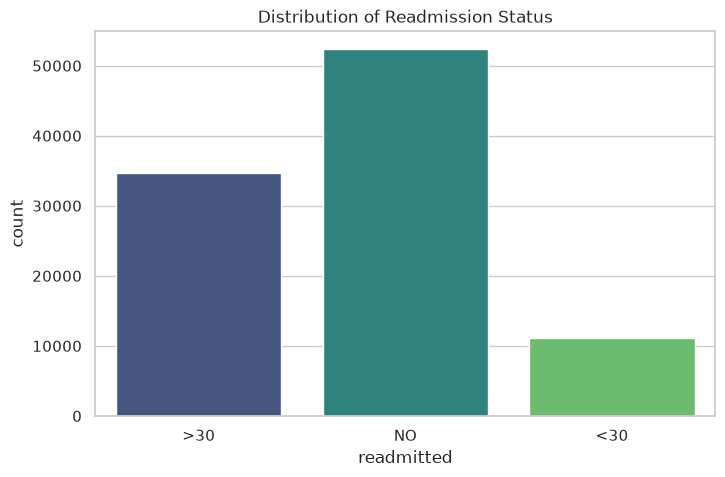

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(x='readmitted', data=df, palette='viridis')
plt.title('Distribution of Readmission Status')
plt.show()

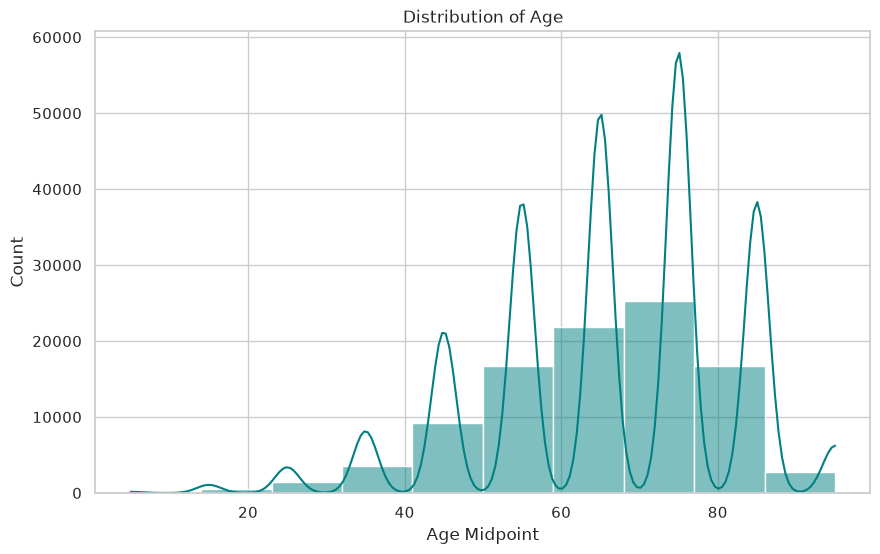

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df['age_numeric'], bins=10, kde=True, color='teal')
plt.title('Distribution of Age')
plt.xlabel('Age Midpoint')
plt.show()

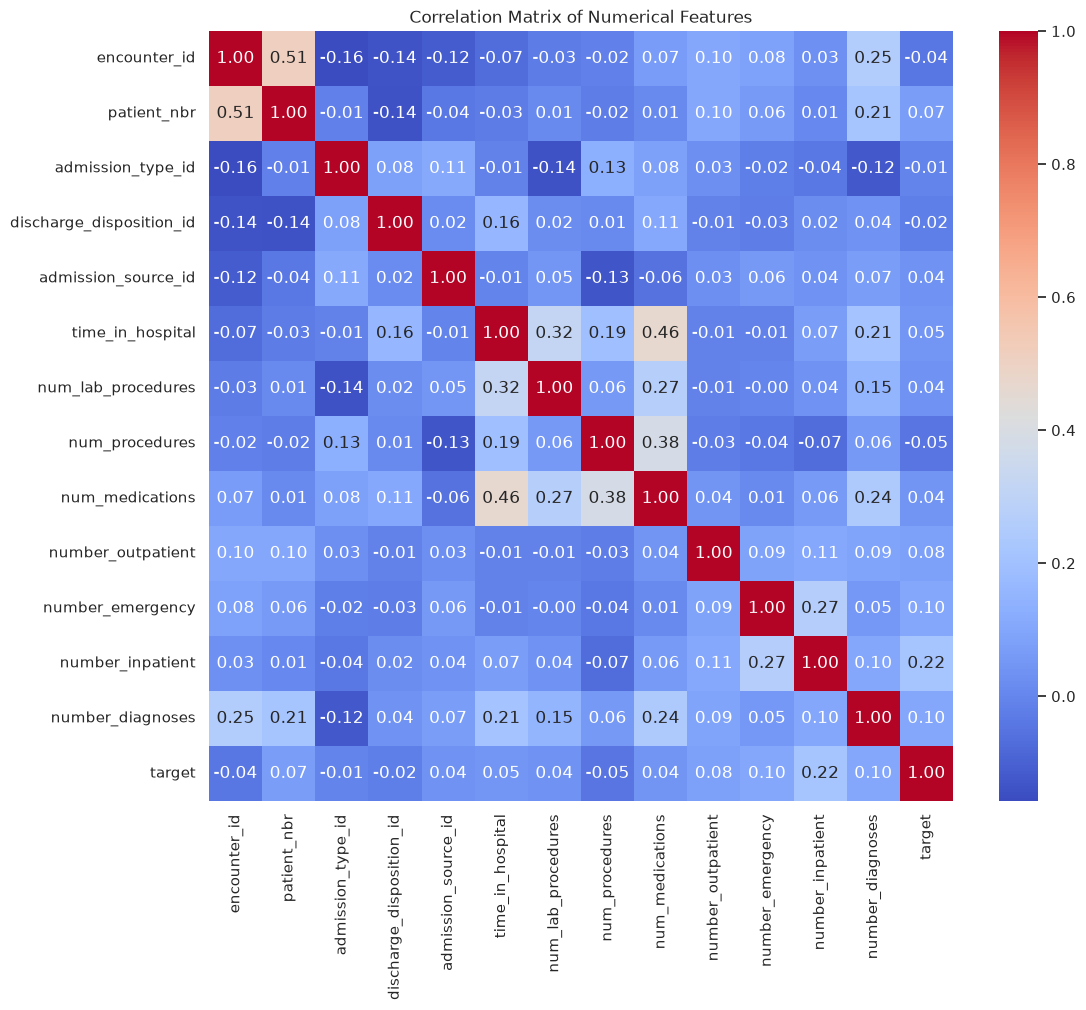

In [12]:
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [13]:
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,age_numeric,target
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,Up,No,No,No,No,Ch,Yes,>30,15,1
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,Yes,NO,25,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,Up,No,No,No,No,Ch,Yes,NO,35,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,Steady,No,No,No,No,Ch,Yes,NO,45,0
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,31,...,Steady,No,No,No,No,No,Yes,>30,55,1
